In [2]:
# Imports + load dataset

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, classification_report

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Load the frozen modeling dataset
dataset = pd.read_parquet("final_modeling_dataset.parquet")

dataset.head()


,hadm_id,text,icd_code
0,23052089,\nName: ___ Unit No: __...,[E785]
1,22927623,\nName: ___ Unit No: ___\n...,"[K219, F419, Z87891]"
2,27988844,\nName: ___ Unit No: ___\n...,"[K219, Z87891, F419, Z7901]"
3,25911675,\nName: ___ Unit No: ___\n \nAdmi...,"[Z23, I2510, Z87891, I252, Z955, I129, Z794, Z..."
4,29659838,\nName: ___ Unit No: ___\n \nAdmi...,"[Z86718, I129, Z955, I2510, Z7901, Z794, I252,..."


In [3]:
# Sanity Check
print("Admissions:", dataset.shape[0])
print("Example labels:", dataset.iloc[0]["icd_code"])

Admissions: 115103
Example labels: ['E785']


In [8]:
# Train/Validation/Test Split

X = dataset["text"]
y = dataset["icd_code"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [10]:
# Multi Label Encoding

mlb = MultiLabelBinarizer()

Y_train = mlb.fit_transform(y_train)
Y_test = mlb.transform(y_test)

print("Number of ICD labels:", len(mlb.classes_))


Number of ICD labels: 50


In [12]:
# Tf-idf vectorization

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=5,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

X_train_tfidf.shape


(92082, 20000)

In [13]:
# Train Baseline Classifier (One-VS-Rest Logistic Regression)

clf = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        solver="liblinear"
    )
)

clf.fit(X_train_tfidf, Y_train)


OneVsRestClassifier(estimator=LogisticRegression(max_iter=2000,
                                                 solver='liblinear'))

In [14]:
# Predictions
Y_pred = clf.predict(X_test_tfidf)

In [15]:
# Core Evaluation Metrics

micro_f1 = f1_score(Y_test, Y_pred, average="micro")
macro_f1 = f1_score(Y_test, Y_pred, average="macro")

print(f"Micro-F1: {micro_f1:.4f}")
print(f"Macro-F1: {macro_f1:.4f}")

Micro-F1: 0.5303
Macro-F1: 0.4179


In [16]:
# Precision @K and Recall @K

def precision_recall_at_k(y_true, y_score, k=5):
    precisions = []
    recalls = []
    
    for i in range(y_true.shape[0]):
        true_labels = set(np.where(y_true[i] == 1)[0])
        top_k = set(np.argsort(y_score[i])[-k:])
        
        if not true_labels:
            continue
            
        precisions.append(len(true_labels & top_k) / k)
        recalls.append(len(true_labels & top_k) / len(true_labels))
    
    return np.mean(precisions), np.mean(recalls)


In [17]:
Y_score = clf.decision_function(X_test_tfidf)

p5, r5 = precision_recall_at_k(Y_test, Y_score, k=5)

print(f"Precision@5: {p5:.4f}")
print(f"Recall@5: {r5:.4f}")


Precision@5: 0.5695
Recall@5: 0.6123


In [18]:
# Label Wise Performance

report = classification_report(
    Y_test,
    Y_pred,
    target_names=mlb.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df.sort_values("f1-score", ascending=False).head(10)


,precision,recall,f1-score,support
E039,0.857957,0.787839,0.821404,3059.0
E785,0.808616,0.721674,0.762675,8817.0
Z794,0.829506,0.689198,0.752871,3092.0
I10,0.811275,0.692716,0.747323,8663.0
I2510,0.818000,0.634671,0.714767,4511.0
K219,0.869514,0.590558,0.703387,6206.0
Z951,0.894866,0.576832,0.701485,1269.0
Z7901,0.800483,0.555109,0.655589,2985.0
D62,0.800156,0.519173,0.629743,1982.0
Z66,0.825590,0.506542,0.627860,2140.0


In [19]:
# Save Baseline Results

baseline_results = {
    "micro_f1": micro_f1,
    "macro_f1": macro_f1,
    "precision_at_5": p5,
    "recall_at_5": r5
}

pd.Series(baseline_results).to_csv("baseline_results.csv")


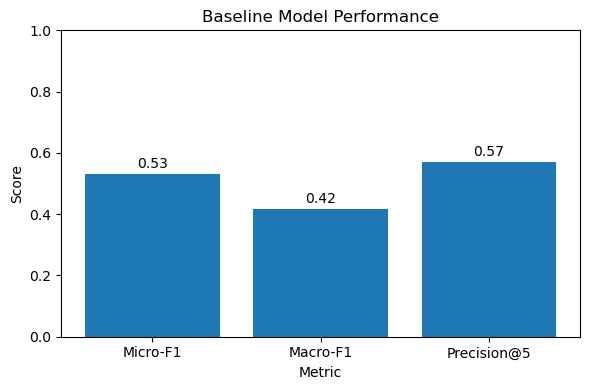

In [29]:
import matplotlib.pyplot as plt

metrics = ["Micro-F1", "Macro-F1", "Precision@5"]
values = [micro_f1, macro_f1, p5]  # use your actual variables

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.ylim(0, 1)
plt.title("Baseline Model Performance")
plt.ylabel("Score")
plt.xlabel("Metric")

for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.savefig("baseline_performance.png")
plt.show()